# LAB 02: Thresholding + Edge Detection for Train Images

This notebook processes all images in `images/train`, creates a binary mask and an edge mask for each image, and saves results to `images/train_masks` and `images/train_edges`.

In [1]:
import os
from pathlib import Path
import cv2
import numpy as np
from matplotlib import pyplot as plt

base_dir = Path(r'c:/Users/alima/OneDrive/Desktop/DIP/DIP/Week 10/LAB_02')
train_dir = base_dir / 'images' / 'train'
mask_dir = base_dir / 'images' / 'train_masks'
edge_dir = base_dir / 'images' / 'train_edges'
mask_dir.mkdir(parents=True, exist_ok=True)
edge_dir.mkdir(parents=True, exist_ok=True)

binary_threshold = 90
edge_threshold = 80

image_files = sorted([p for p in train_dir.iterdir() if p.suffix.lower() in ('.jpg', '.png', '.jpeg')])
print('Found', len(image_files), 'images in', train_dir)

def process_image(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f'Cannot read {path}')

    _, mask = cv2.threshold(img, binary_threshold, 255, cv2.THRESH_BINARY)

    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx ** 2 + sobely ** 2)
    grad_mag = np.uint8(np.clip((grad_mag / (grad_mag.max() if grad_mag.max() != 0 else 1)) * 255, 0, 255))
    _, edge_mask = cv2.threshold(grad_mag, edge_threshold, 255, cv2.THRESH_BINARY)

    cv2.imwrite(str(mask_dir / f'{path.stem}_mask.png'), mask)
    cv2.imwrite(str(edge_dir / f'{path.stem}_edge.png'), edge_mask)

    return img, mask, grad_mag, edge_mask

for i, p in enumerate(image_files, start=1):
    process_image(p)
    if i % 50 == 0:
        print(f'Processed {i}/{len(image_files)} images')

print('Done processing all images.')

Found 200 images in c:\Users\alima\OneDrive\Desktop\DIP\DIP\Week 10\LAB_02\images\train
Processed 50/200 images
Processed 100/200 images
Processed 150/200 images
Processed 200/200 images
Done processing all images.


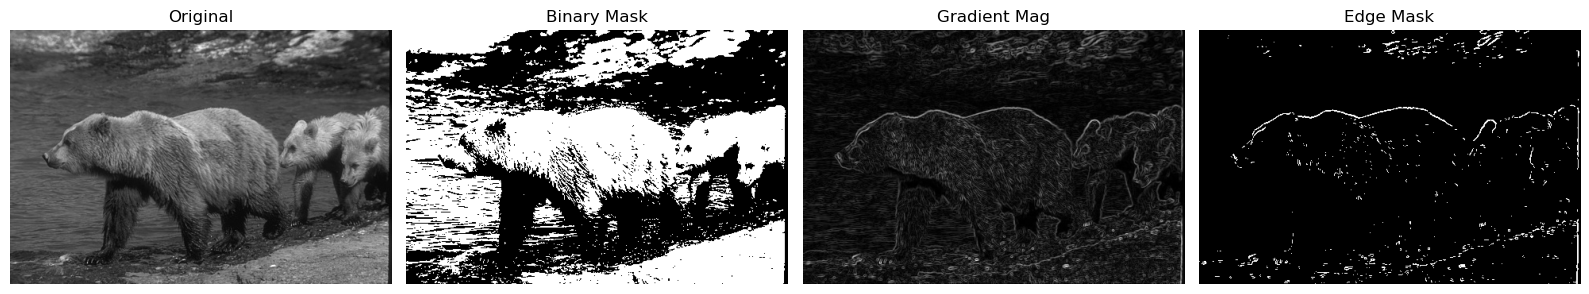

In [2]:
if image_files:
    sample = image_files[0]  # display first image
    img, mask, grad_mag, edge_mask = process_image(sample)
    plt.figure(figsize=(16, 4))
    for idx, (title, mat) in enumerate([
        ('Original', img),
        ('Binary Mask', mask),
        ('Gradient Mag', grad_mag),
        ('Edge Mask', edge_mask),
    ]):
        ax = plt.subplot(1, 4, idx + 1)
        ax.imshow(mat, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()